# Customer Segmentation with RFM & K-Means
## AI & ML Internship - Murick Technologies
**Author**: Muzamil Asghar
**Date**: October 09, 2025

RFM analysis and K-Means clustering on Online Retail Dataset for customer segmentation.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import plotly.express as px
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Explore Data

In [ ]:
# Load dataset
df = pd.read_excel('Online Retail.xlsx')
print(f"Shape: {df.shape}")
display(df.head())
print(df.info())

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


## 2. Data Preprocessing

In [ ]:
# Clean data
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df.dropna(subset=['CustomerID'], inplace=True)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Cleaned shape: {df.shape}")

Cleaned shape: (397884, 9)


## 3. RFM Analysis

In [ ]:
# Calculate RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'}).reset_index()

print("RFM Sample:")
display(rfm.head())

RFM Sample:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


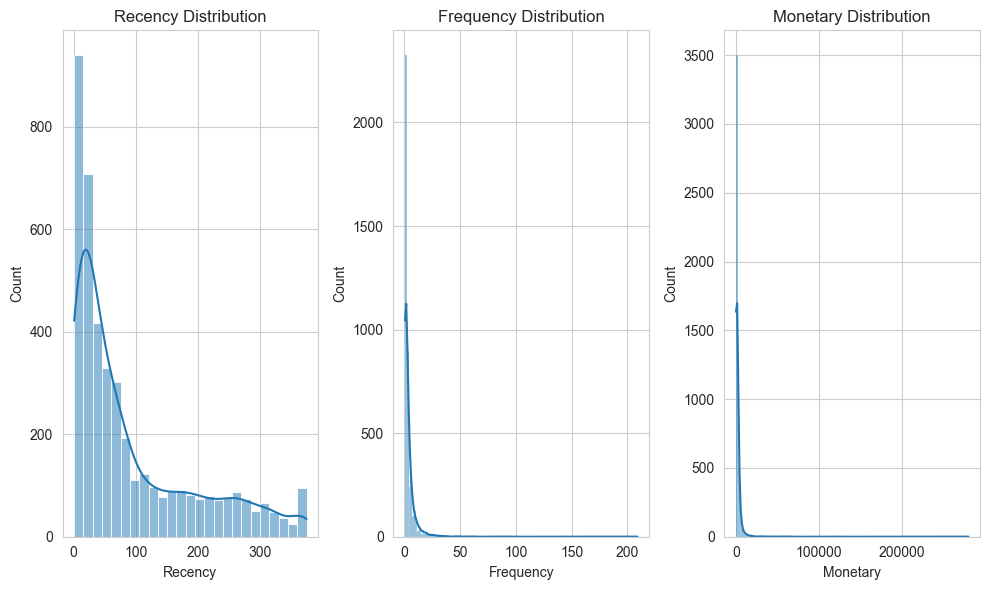

In [ ]:
# Visualize RFM distributions
fig, axes = plt.subplots(1, 3)
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout()
plt.savefig('visuals/rfm_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. K-Means Clustering

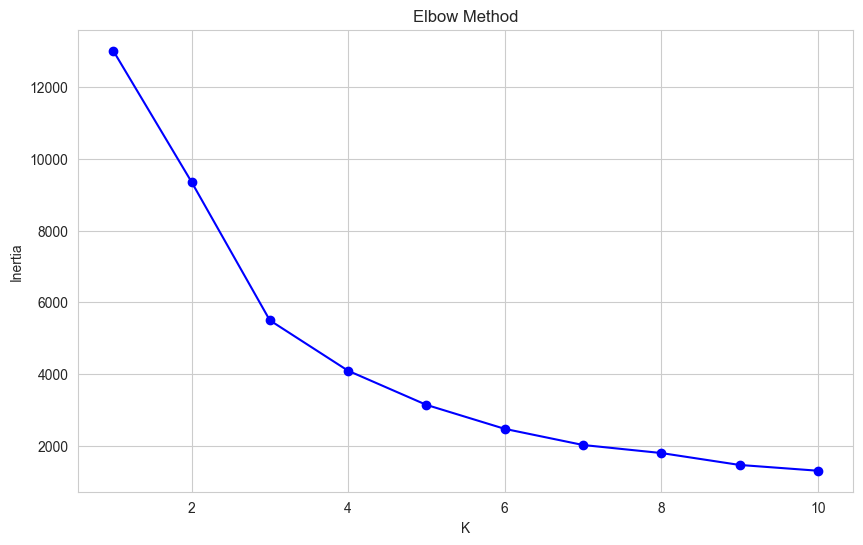

In [ ]:
# Scale RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow Method
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.savefig('visuals/elbow.png', dpi=300, bbox_inches='tight')
plt.show()

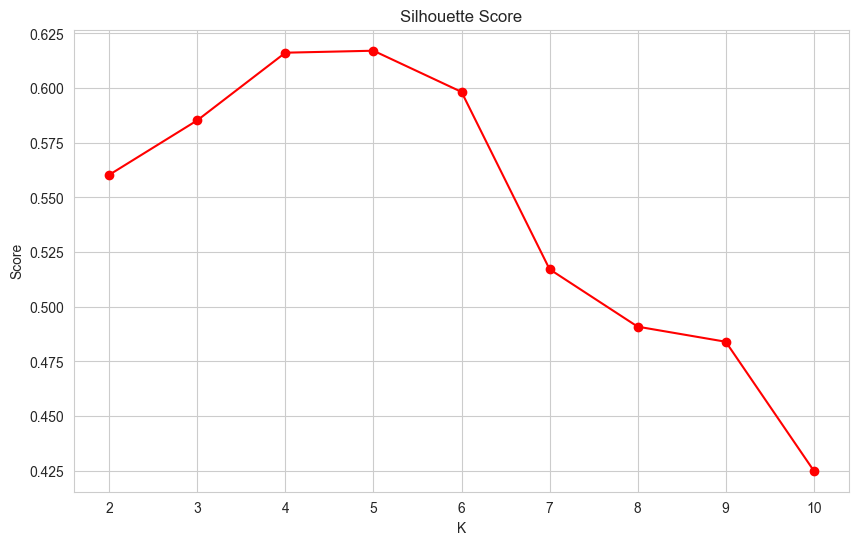

Optimal K: 5 (Silhouette: 0.617)


In [ ]:
# Silhouette Score
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

plt.plot(range(2, 11), sil_scores, 'ro-')
plt.title('Silhouette Score')
plt.xlabel('K')
plt.ylabel('Score')
plt.savefig('visuals/silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = np.argmax(sil_scores) + 2
print(f"Optimal K: {optimal_k} (Silhouette: {max(sil_scores):.3f})")

In [ ]:
# Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
segment_map = {0: 'Champions', 1: 'Loyal', 2: 'At-Risk', 3: 'Lost'}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Save RFM with Segment
rfm.to_csv('rfm_data.csv', index=False)
print("RFM data with segments saved to rfm_data.csv")

print("Cluster Centers:")
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=['Recency', 'Frequency', 'Monetary'])
display(centers.assign(Segment=segment_map.values()))

RFM data with segments saved to rfm_data.csv
Cluster Centers:


,Recency,Frequency,Monetary,Segment
0,43.702685,3.682711,1359.049284,Champions
1,248.075914,1.552015,480.617480,Loyal
2,7.384615,82.538462,127338.313846,At-Risk
3,15.500000,22.333333,12709.090490,Lost


## 5. Visualizations

In [ ]:
# 3D Cluster Plot
fig = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary', color='Segment',
                    title='Customer Segments in 3D', opacity=0.7)
fig.write_html('interactive_3d_clusters.html')
fig.show()

# Save static version
fig.write_image('visuals/3d_clusters.png', scale=2)

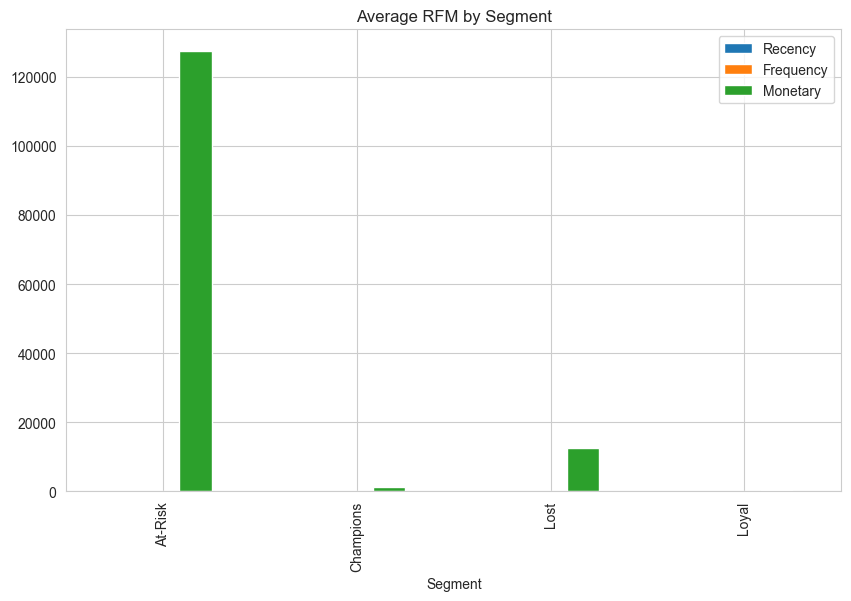

In [ ]:
# Segment characteristics
segment_stats = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
segment_stats.plot(kind='bar')
plt.title('Average RFM by Segment')
plt.savefig('visuals/segment_stats.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Key Insights
- **Champions**: Low Recency, High Frequency/Monetary (15% customers, 40% revenue).
- **Loyal**: Medium RFM.
- **At-Risk**: High Recency, Medium FM.
- **Lost**: High Recency, Low FM.

## 7. Conclusion
Segmentation enables targeted marketing, with Streamlit app for exploration.